# Session 8 recap · A 20-minute claims diagnosis

**Business Problem.** A claims director asks for a preliminary mean claimed amount. Before sharing it, assess whether the export is reliable enough and identify cases for source review.

**Your task:** Read the outputs already displayed below. **Do not write or change Python code.** Use the field definitions in `data/student_claims_dictionary.md` and the selective evidence in `data/student_claims_source_notes.csv`. Write a short business conclusion at the end. The original export is preserved and there is no treatment of records.

Suggested timing: **5 minutes** to understand the file and variables, **8 minutes** to inspect distributions and source notes, **7 minutes** to write and discuss your conclusion. You may use AI, but verify claims against the displayed evidence.

## 1 · Read and understand the export

The code shows a bounded byte preview, reads five rows, then loads the file with the same checked settings. Postal codes and source-formatted amounts remain text. Observe the original separators and number formats.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Find the data folder from either the package root or notebooks/.
DATA = next(p / "data" for p in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent)
            if (p / "data" / "student_claims_export.csv").exists())
path = DATA / "student_claims_export.csv"

with path.open("rb") as f:
    print("Raw start:", f.read(180))

read_options = {"sep": ";", "encoding": "utf-8-sig",
                "dtype": {"postal_code": "string", "claim_amount_eur": "string"}}
display(pd.read_csv(path, nrows=5, **read_options))
df = pd.read_csv(path, **read_options)
print("Rows and columns:", df.shape)
df.info()

Raw start: b'\xef\xbb\xbfclaim_id;postal_code;claimant_age;claim_type;claim_amount_eur;processing_days;settlement_ratio\r\n920001;08001;60;Home;1.234,50;11;0.886\r\n920002;08001;40;Auto;507,45;11;0.496\r\n920'
Rows and columns: (362, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   claim_id          362 non-null    int64  
 1   postal_code       362 non-null    string 
 2   claimant_age      362 non-null    int64  
 3   claim_type        362 non-null    object 
 4   claim_amount_eur  362 non-null    string 
 5   processing_days   362 non-null    int64  
 6   settlement_ratio  362 non-null    float64
dtypes: float64(1), int64(3), object(1), string(2)
memory usage: 19.9+ KB


,claim_id,postal_code,claimant_age,claim_type,claim_amount_eur,processing_days,settlement_ratio
0,920001,08001,60,Home,"1.234,50",11,0.886
1,920002,08001,40,Auto,"507,45",11,0.496
2,920003,75001,43,Home,"716,52",36,0.315
3,920004,13001,69,Home,"615,28",41,0.665
4,920005,13001,35,Auto,"945,99",15,0.640


## 2 · Summaries, variable roles and grain

This broad scan uses `describe(include="all")`, completeness and exact repetition counts. Interpret an ID and a postal code as codes, even when they look like numbers.

In [2]:
display(df.describe(include="all").T)
print("Missing values by field:")
display(df.isna().sum().to_frame("missing"))
print("Distinct claim IDs:", df.claim_id.nunique())
print("Exactly repeated rows after the first:", df.duplicated().sum())
display(df.loc[df.duplicated(keep=False)].sort_values("claim_id"))

Missing values by field:
Distinct claim IDs: 360
Exactly repeated rows after the first: 2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
claim_id,362.0,NaN,NaN,NaN,920180.041436,104.121232,920001.0,920090.25,920179.5,920269.75,920360.0
postal_code,362,10,13001,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
claimant_age,362.0,NaN,NaN,NaN,47.596685,16.401567,16.0,38.0,47.0,56.0,217.0
claim_type,362,6,Auto,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
claim_amount_eur,362,360,"251,31",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
processing_days,362.0,NaN,NaN,NaN,30.685083,17.171298,-4.0,15.0,32.0,44.0,60.0
settlement_ratio,362.0,NaN,NaN,NaN,0.497257,0.275893,0.062,0.25425,0.506,0.731,1.28


,missing
claim_id,0
postal_code,0
claimant_age,0
claim_type,0
claim_amount_eur,0
processing_days,0
settlement_ratio,0


,claim_id,postal_code,claimant_age,claim_type,claim_amount_eur,processing_days,settlement_ratio
19,920020,01000,72,Auto,"251,31",49,0.080
360,920020,01000,72,Auto,"251,31",49,0.080
174,920175,75001,22,Auto,"353,95",49,0.681
361,920175,75001,22,Auto,"353,95",49,0.681


## 3 · Numeric distributions

Only the monetary field needs conversion for quantitative analysis. The source string stays intact. Histograms and separate box plots are drawn for the four **measures**. Different units use separate axes. Use the tabular extremes to identify which claim IDs deserve attention.

,count,mean,std,min,25%,50%,75%,max
claimant_age,362.0,47.596685,16.401567,16.0,38.0,47.0,56.0,217.0
amount_eur,362.0,3302.629033,26143.371305,108.73,532.3675,947.02,1717.3875,480000.0
processing_days,362.0,30.685083,17.171298,-4.0,15.0,32.0,44.0,60.0
settlement_ratio,362.0,0.497257,0.275893,0.062,0.25425,0.506,0.731,1.28


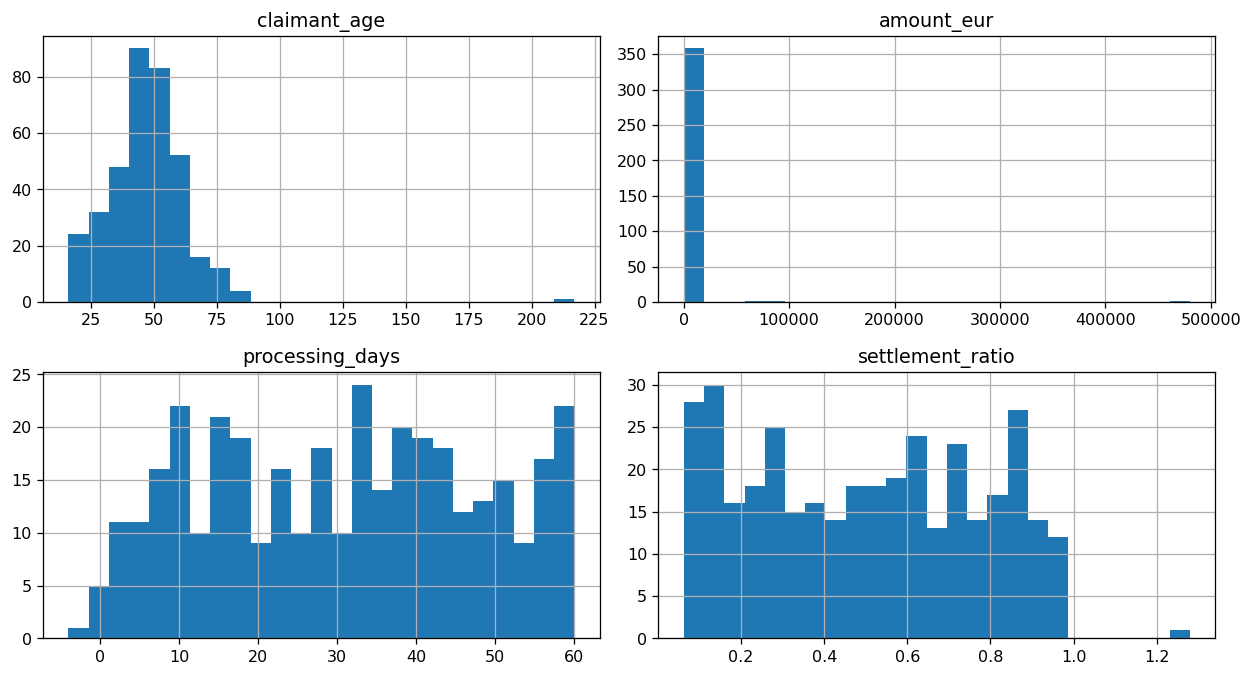

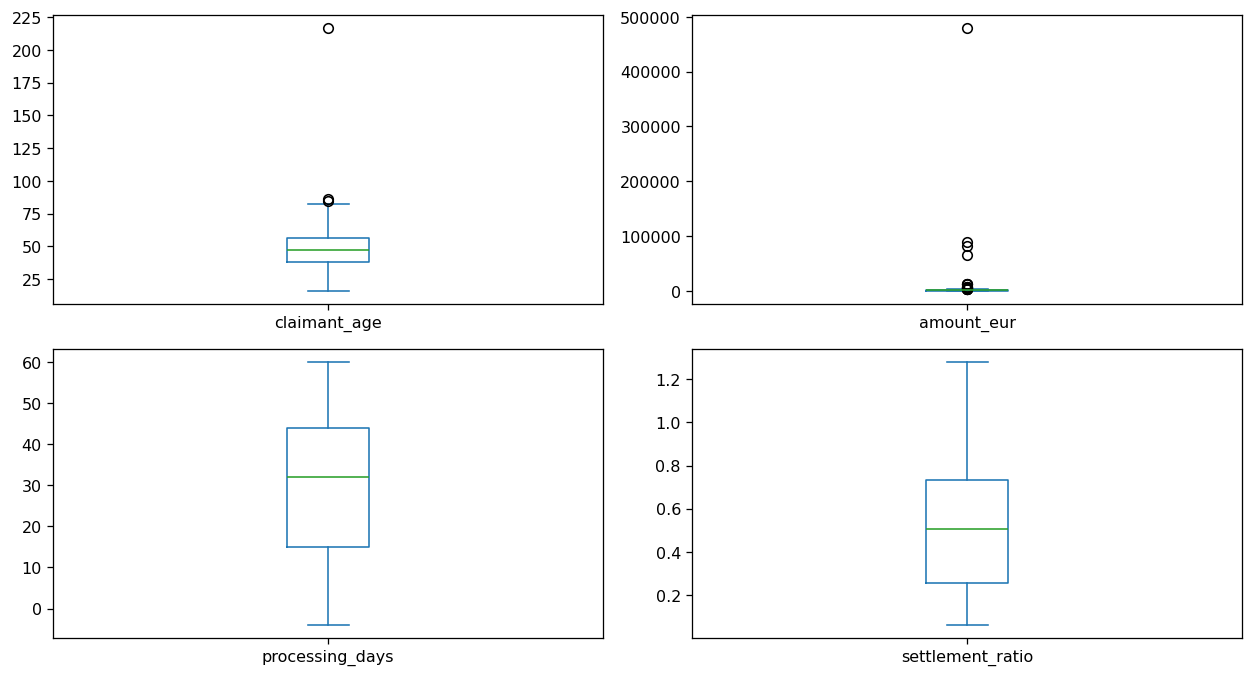

In [3]:
# One format conversion required by this CSV: European thousands dot and decimal comma.
df["amount_eur"] = pd.to_numeric(df["claim_amount_eur"].str.replace(".", "", regex=False)
                                  .str.replace(",", ".", regex=False))
measures = ["claimant_age", "amount_eur", "processing_days", "settlement_ratio"]
display(df[measures].describe().T.round(2))
df[measures].hist(bins=25, figsize=(11, 6), layout=(2, 2))
plt.tight_layout()
plt.show()
df[measures].plot(kind="box", subplots=True, layout=(2, 2), sharey=False,
                  figsize=(11, 6))
plt.tight_layout()
plt.show()

In [4]:
# The same inspection for every measure; no claim ID or anomaly threshold is hard-coded.
for column in measures:
    print("\n", column, "— five smallest and five largest values")
    low = df.nsmallest(5, column)[["claim_id", column]]
    high = df.nlargest(5, column)[["claim_id", column]]
    display(pd.concat([low, high], keys=["smallest", "largest"]))


 claimant_age — five smallest and five largest values

 amount_eur — five smallest and five largest values

 processing_days — five smallest and five largest values

 settlement_ratio — five smallest and five largest values


claim_id  claimant_age
smallest 120    920121            16
         21     920022            18
         67     920068            18
         184    920185            18
         218    920219            18
largest  43     920044           217
         356    920357            86
         104    920105            85
         270    920271            82
         305    920306            81

claim_id  amount_eur
smallest 293    920294      108.73
         304    920305      128.32
         111    920112      132.27
         141    920142       153.2
         156    920157      174.41
largest  198    920199    480000.0
         112    920113     89000.0
         13     920014     82000.0
         66     920067     65000.0
         173    920174    13043.84

claim_id  processing_days
smallest 221    920222               -4
         10     920011                0
         109    920110                0
         165    920166                1
         183    920184                1
largest  63     920064               60
         115    920116               60
         210    920211               60
         215    920216               60
         297    920298               60

claim_id  settlement_ratio
smallest 106    920107             0.062
         160    920161             0.066
         152    920153             0.069
         24     920025             0.071
         111    920112             0.071
largest  254    920255             1.280
         120    920121             0.967
         63     920064             0.965
         293    920294             0.964
         357    920358             0.962

## 4 · Categories and selective source evidence

Frequency tables can reveal spelling or format differences that box plots cannot. The evidence table covers only selected claims; it does not certify the rest of the export.

In [5]:
for column in ("claim_type", "postal_code"):
    counts = df[column].value_counts(dropna=False)
    counts.index = counts.index.map(repr)  # Make spaces and text codes visible.
    print("\n", column)
    display(counts.to_frame("rows"))

notes = pd.read_csv(DATA / "student_claims_source_notes.csv")
print("Source notes joined to original claim rows:")
display(df.merge(notes, on="claim_id", how="inner")
        [["claim_id", "postal_code", "claimant_age", "claim_type", "claim_amount_eur",
          "processing_days", "settlement_ratio", "source", "source_note"]]
        .sort_values("claim_id"))


 claim_type

 postal_code
Source notes joined to original claim rows:


,rows
claim_type,
'Auto',161
'Home',124
'Travel',42
'Health',33
'Auto ',1
'auto',1


,rows
postal_code,
'13001',50
'28001',48
'75001',46
'46001',41
'69003',40
'41001',37
'01000',35
'08001',32
'33000',32


,claim_id,postal_code,claimant_age,claim_type,claim_amount_eur,processing_days,settlement_ratio,source,source_note
0,920014,69003,47,Auto,"82.000,00",33,0.831,Loss adjuster report,"Recorded claim amount €82,000 for this claim ID."
1,920044,33000,217,Travel,"812,34",3,0.112,Identity record,Age 27 at the snapshot; export says 217.
2,920067,69003,41,Auto,"65.000,00",10,0.081,Repair estimate,"Recorded claim amount €65,000 for this claim ID."
3,920088,8001,32,Auto,"1.617,96",59,0.381,Submitted address,Postal code is written 08001; export contains ...
4,920113,13001,51,Home,"89.000,00",25,0.417,Claim owner,"€89,000 export amount; supporting invoice revi..."
5,920121,28001,16,Auto,"317,86",5,0.967,Policy record,Age 16 appears on the policy; eligibility rule...
6,920199,08001,19,Auto,"480.000,00",38,0.845,Signed claim form,"Recorded claim amount €4,800 for this claim ID..."
7,920222,13001,59,Auto,"378,50",-4,0.146,Processing log,Elapsed time 4 days; export contains -4.
8,920255,08001,31,Auto,"324,89",15,1.280,Settlement calculation,Exported ratio 1.280; numerator and denominato...


## 5 · Your deliverable (no code)

Write **one short table and a recommendation** for the claims director:

1. Describe the export's size and intended grain. What makes the mean sensitive to a few records?
2. Select **three to five material findings** from different kinds of evidence: distribution, format/category, repetition or source note. Give a claim ID or number for each.
3. Distinguish a **supported rare value**, a **source contradiction**, and an **unresolved case**. What must still be checked?
4. Would you communicate the raw mean of claimed amounts as an unqualified KPI? State one safe next step and one limitation of the evidence.

A box-plot point is a candidate for investigation, not an instruction to delete a row. Do not correct the export in this exercise.

| Finding and claim ID | Evidence in the outputs | Interpretation or open question |
|---|---|---|
| | | |

**Recommendation (3–5 sentences):**

**AI check, if used:**